In [1]:
import numpy as np
from models.PP3DR_Dino import PP3DR_Dino
import torch
from datasets.nrgbd_dataset import nrgbd_dataset
import matplotlib.pyplot as plt

/vulcanscratch/hughma/miniconda3/envs/Pi3/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = PP3DR_Dino()

loaded_state_dict = torch.load("/vulcanscratch/hughma/PP3DR/sanity_monodepth/PP3DR.pth", weights_only=True)
# The lines here are necessary if all the loaded state dict entries begin with an extra "module."
new_state_dict = {}
for key in loaded_state_dict:
    new_state_dict[key[7:]] = loaded_state_dict[key]
model.load_state_dict(new_state_dict)

model = model.eval().to("cuda")
dataset = nrgbd_dataset()
data = dataset[0]
for key in data:
    data[key] = data[key].unsqueeze(0)
with torch.amp.autocast("cuda", dtype = torch.bfloat16), torch.no_grad():
    pred = model(data['images'].to("cuda"))
for key in pred:
    pred[key] = pred[key].to(torch.float32).cpu().numpy(force=True)
    print(f"{key}: {pred[key].shape}")

Loading weights: 100%|██████████| 615/615 [00:00<00:00, 2301.41it/s]
Precomputing NRGBD image file paths: 9it [00:00, 22.57it/s]
/vulcanscratch/hughma/miniconda3/envs/Pi3/lib/python3.14/site-packages/torch/_dynamo/variables/functions.py:2056: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
  torch._dynamo.utils.warn_once(msg)
/vulcanscratch/hughma/miniconda3/envs/Pi3/lib/python3.14/site-packages/torch/_dynamo/utils.py:3694: UserWarning: Mismatch dtype between input and weight: input dtype = c10::BFloat16, weight dtype = float, Cannot dispatch to fused implementation. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/native/layer_norm.cpp:344.)
  return node.target(*args, **kwargs)  # type:

XY_rays: (1, 10, 480, 640, 2)
log_depths: (1, 10, 480, 640)


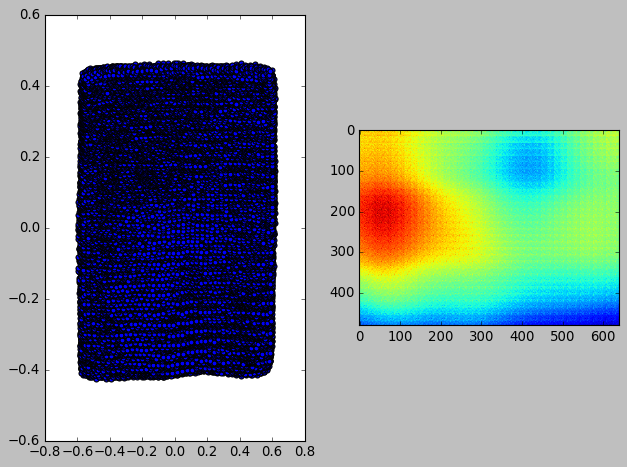

In [3]:
# plt.style.use("seaborn-v0_8-darkgrid")
plt.style.use("classic")
fig, (a1, a2) = plt.subplots(1, 2)
a1.scatter(pred['XY_rays'][0, 0][..., 0], pred['XY_rays'][0, 0][..., 1])
a2.imshow(pred['log_depths'][0][0])
fig.tight_layout()

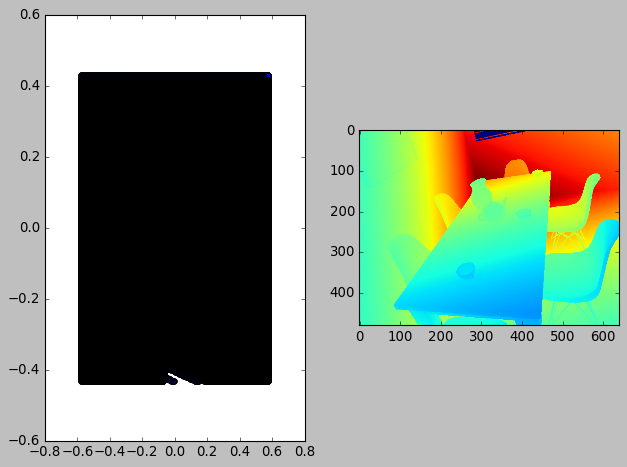

In [4]:
def obtain_gt_3D_points(gt):
    """
    Parameters
    ----------
    gt

    Returns
    -------
    (B, L, H, W, 3) of world-frame 3D-coordinates, unprojected from gt, UN-NORMALISED.
    We won't normalize here; we'll normalize in the main function.
    """
    B, L, H, W = gt['depths'].shape
    y, x = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    Z = gt['depths'].to("cuda", non_blocking = True)
    gt['intrinsic'] = gt['intrinsic'].to("cuda", non_blocking = True)
    fx, fy, cx, cy = gt['intrinsic'][:, 0, 0], gt['intrinsic'][:, 1, 1], gt['intrinsic'][:, 0, 2], gt['intrinsic'][:, 1, 2]
    X = (x.to("cuda", non_blocking = True) - cx) * Z / fx
    Y = (y.to("cuda", non_blocking = True) - cy) * Z / fy
    return torch.stack((X, Y, Z), dim=-1) # (B, N, H, W, 3)

gt_points = obtain_gt_3D_points(data) # (B, N, H, W, 3)
gt_points = gt_points[0, 0]
gt_xy = gt_points[..., :2] / gt_points[..., 2:]
gt_xy = gt_xy.numpy(force = True)
fig, (a1, a2) = plt.subplots(1, 2)
a1.scatter(gt_xy[..., 0], gt_xy[..., 1])
a2.imshow(data['depths'][0][0])
fig.tight_layout()